In [45]:
import femm
import matplotlib.pyplot as plt

# 1. PARAMÈTRES DE VOTRE SIMULATION

In [46]:

fichier_fem = "model_rot.fem"  # Mettez le chemin exact vers votre fichier FEMM
groupe_mobile = 1               # Le numéro du groupe de votre aimant/rotor
x_pivot = 0.0                   # Coordonnée X du centre de rotation
y_pivot = 0.0                   # Coordonnée Y du centre de rotation

angle_depart = -10
angle_fin = 190                  # On va faire tourner la pièce jusqu'à 90 degrés
pas_angle = 2                 # On fait une mesure tous les 5 degrés

# Listes pour stocker nos résultats
liste_angles = []
liste_energies = []

# 2. DÉMARRAGE DE FEMM

In [47]:
print("Démarrage de FEMM...")
femm.openfemm()
femm.opendocument(fichier_fem)

# Astuce de pro : on sauvegarde sous un nom temporaire 
# pour ne pas écraser votre fichier original avec la pièce tournée !
femm.mi_saveas("temp_simulation_rotation.fem")

Démarrage de FEMM...


# 3. LA BOUCLE DE ROTATION ET DE CALCUL

In [48]:
print("Début des calculs...")

for angle in range(angle_depart, angle_fin + 1, pas_angle):
    print(f"Calcul pour l'angle : {angle}°")
    
    # a. Lancer le calcul (les engrenages jaunes)
    femm.mi_analyze()
    
    # b. Charger les résultats (les lunettes)
    femm.mi_loadsolution()
    
    # c. Sélectionner les zones pour calculer l'énergie
    # Ici, on sélectionne tout le modèle en appelant tous les groupes utilisés (ex: 0 et 1)
    # Adaptez si vous avez mis des numéros de groupes différents pour le stator/air.
    femm.mo_groupselectblock(0) 
    femm.mo_groupselectblock(1) 
    
    # d. Calculer l'énergie magnétique stockée (Code de l'intégrale = 11 dans FEMM)
    energie_joules = femm.mo_blockintegral(2)
    
    # e. Sauvegarder les valeurs dans nos listes
    liste_angles.append(angle)
    liste_energies.append(energie_joules)
    
    # f. Fermer la fenêtre de résultats
    femm.mo_close()
    
    # g. Faire tourner la pièce pour la PROCHAINE étape de la boucle
    # On sélectionne tout le groupe, et on le fait tourner du "pas_angle"
    femm.mi_selectgroup(groupe_mobile)
    femm.mi_moverotate(x_pivot, y_pivot, pas_angle)

# On ferme FEMM proprement à la fin
print("Calculs terminés. Fermeture de FEMM.")
femm.closefemm()

Début des calculs...
Calcul pour l'angle : -10°
Calcul pour l'angle : -8°
Calcul pour l'angle : -6°
Calcul pour l'angle : -4°
Calcul pour l'angle : -2°
Calcul pour l'angle : 0°
Calcul pour l'angle : 2°
Calcul pour l'angle : 4°
Calcul pour l'angle : 6°
Calcul pour l'angle : 8°
Calcul pour l'angle : 10°
Calcul pour l'angle : 12°
Calcul pour l'angle : 14°
Calcul pour l'angle : 16°
Calcul pour l'angle : 18°
Calcul pour l'angle : 20°
Calcul pour l'angle : 22°
Calcul pour l'angle : 24°
Calcul pour l'angle : 26°
Calcul pour l'angle : 28°
Calcul pour l'angle : 30°
Calcul pour l'angle : 32°
Calcul pour l'angle : 34°
Calcul pour l'angle : 36°
Calcul pour l'angle : 38°
Calcul pour l'angle : 40°
Calcul pour l'angle : 42°
Calcul pour l'angle : 44°
Calcul pour l'angle : 46°
Calcul pour l'angle : 48°
Calcul pour l'angle : 50°
Calcul pour l'angle : 52°
Calcul pour l'angle : 54°
Calcul pour l'angle : 56°
Calcul pour l'angle : 58°
Calcul pour l'angle : 60°
Calcul pour l'angle : 62°
Calcul pour l'angle :

In [49]:
print(liste_energies)

[3.910911368838289, 3.895519726285881, 3.875482526532287, 3.853347956582371, 3.831346258334357, 3.81045989030417, 3.792435433813758, 3.777986966719817, 3.767872735507926, 3.762025142028339, 3.7598026068378, 3.76018650146729, 3.762021745018738, 3.764834757997559, 3.767881906673896, 3.771146749599948, 3.774498190146503, 3.77787327771679, 3.781496687848069, 3.785149303928764, 3.788500064248024, 3.791969210144506, 3.795080704818512, 3.797742312707478, 3.800498048858414, 3.803349971721457, 3.806149787306698, 3.809405950215933, 3.812776650535297, 3.816025772908416, 3.818954599261766, 3.820932706897901, 3.82116636495017, 3.818406985703491, 3.812311235301776, 3.801951588895682, 3.786992172642581, 3.768644226955612, 3.748240073067564, 3.727415821789646, 3.707912190168437, 3.690469734148882, 3.677946948975678, 3.671673115736462, 3.672568375105903, 3.680556894339938, 3.694979535288151, 3.714088644920444, 3.735420027513304, 3.757889093237483, 3.779091754934091, 3.798362705892245, 3.81402660853014,

# 4. AFFICHAGE DU GRAPHIQUE (Matplotlib)

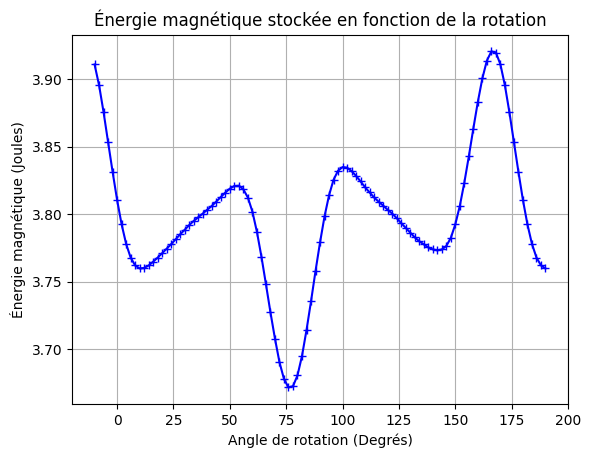

In [50]:
# On trace la courbe avec nos listes, en mettant des points (marker='o')
plt.plot(liste_angles, liste_energies, marker='+', linestyle='-', color='b')

# Personnalisation du graphique
plt.title("Énergie magnétique stockée en fonction de la rotation")
plt.xlabel("Angle de rotation (Degrés)")
plt.ylabel("Énergie magnétique (Joules)")
plt.grid(True) # Ajoute la grille en fond

# On affiche le graphique à l'écran !
plt.show()

In [51]:
#dérivée numérique pour trouver le couple électromagnétique
couple_electromagnetique = []
for i in range(1, len(liste_energies)):
    dE = liste_energies[i] - liste_energies[i-1]
    dTheta = (liste_angles[i] - liste_angles[i-1]) * (3.14159 / 180)  # Convertir en radians
    couple = dE / dTheta
    couple_electromagnetique.append(couple)

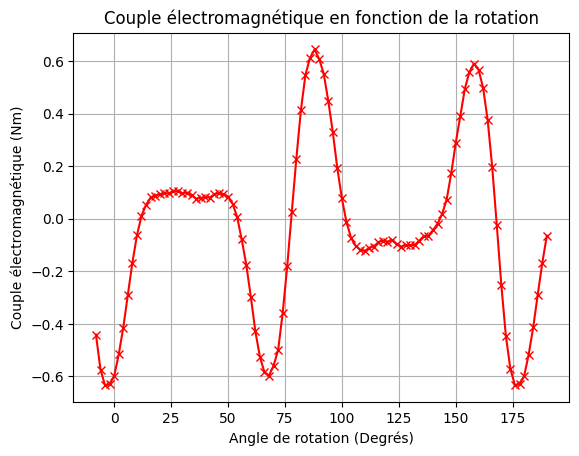

In [53]:
plt.plot(liste_angles[1:], couple_electromagnetique, marker='x', linestyle='-', color='r')
plt.title("Couple électromagnétique en fonction de la rotation")
plt.xlabel("Angle de rotation (Degrés)")
plt.ylabel("Couple électromagnétique (Nm)")
plt.grid()